# TS Dynamic Pricing Algorithm Results Analysis

This notebook accompanies the  [Thompson Sampling (TS) Dynamic Pricing Tutorial paper](./dyanamic_pricing_ts.md). 


* Simulation Results

# Imports 

In [5]:
# Good to know the Python version
!python --version

Python 3.12.7


In [6]:
# General Imports
import numpy as np
import pandas as pd
import beautifulplots as bp
#import matplotlib.pyplot as plt
import json

#import pymc as pm

import arviz as az
from pathlib import Path
import json
from io import StringIO

import matplotlib.pyplot as plt


# Load Simulation Results

In [ ]:
# Sim Results File

###---- case 2 ----#####

# 202604190748
#  - Nrounds = 30
#  - N_price_repeat = 3
#  - limit_price_change = True
#  - max_price_change_1,2 = 1,.025
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.79, p_optest = 2.71
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604190748.json" 


# 2604191845
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.025
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.806, p_optest = 2.69
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604191845.json" 

#202604191905
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.025
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.79, p_optest = 2.67
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604191905.json" 

# 202604191917
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.025
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.816, p_optest = 2.67
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604191917.json" 

# 202604200710
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.05
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.768, p_optest = 2.76
# comment: 
#   - 2.5% local deviation not enough. - 2.5% from p_opt is barely getting to 2.7 opt price
#   - otherewise very nice example of convergence
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604200710.json" 


# 202604200745
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.05
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.81  p_optest = 2.69
# comment: 
#   - 5% local deviation not enough. - 2.5% from p_opt is barely getting to 2.7 opt price
#   - initial p_optest very low but then converges over all the way to the end
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604200745.json" 

# 202604210422
#  - Nrounds = 30
#  - limit_price_change = True
#  - N_price_repeat = 3
#  - max_price_change_1,2 = 1,.05
#  - price_anchor_1,2 = False, True
#  - a_fixed = False, CV_a = 0.5, m_a_linear = 3900
#  - fix_sigma_log = True
#  - Nk = 15
#  - K1, K2 = 2,1
# - v_mean = 1.81  p_optest = 2.69
# comment: 
#   - 5% local deviation not enough. - 2.5% from p_opt is barely getting to 2.7 opt price
#   - initial p_optest very low but then converges over all the way to the end
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604210422.json" 


### -----copy the desired line (from above) here ------####
sim_results_file = "./data_sim_results/ts_sim_results_case2_202604191917.json" 



In [28]:
# Load
print(f'Loading sim results from {sim_results_file}')

with open(sim_results_file, 'r') as f:
    sim_results_dict = json.load(f)
    
# Load PyMC Traces
traces_dir = Path(sim_results_dict['traces_dir'])
n_traces = sim_results_dict['n_traces']

_traces = [
    az.from_netcdf(traces_dir / f"trace_t{t:03d}.nc")
    for t in range(1, n_traces + 1)
]

print(f'n_traces loaded = {len(_traces)}')

Loading sim results from ./data_sim_results/ts_sim_results_case2_202604191917.json
n_traces loaded = 30


In [29]:
case = sim_results_dict['example_case']
K1 = sim_results_dict["K1"]
K2 = sim_results_dict["K2"]
Nk = sim_results_dict.get("Nk")
Nrounds = sim_results_dict.get("Nrounds")
N_price_repeat = sim_results_dict.get("Nth_new_price") # new variable

price_anchor_1 = sim_results_dict.get("price_anchor_1")
price_anchor_2 = sim_results_dict.get("price_anchor_2")
price_min = sim_results_dict["hyperparameters"]["min_price"]
price_max = sim_results_dict["hyperparameters"]["max_price"]

max_price_change_1 = sim_results_dict.get("max_price_change_1")
max_price_change_2 = sim_results_dict.get("max_price_change_2")
repeat_deviation_1 = sim_results_dict.get("repeat_deviation_1")
repeat_deviation_2 = sim_results_dict.get("repeat_deviation_2")
initial_prices = sim_results_dict["initial_prices"]
sim_variables_str = """
   v_history = v_mean
   a_history = a_mean
   cv_history = cv_mean
   sigma_log_history = sigma_log_mean
   price_optest_history = p_opt_est
"""
print("df_variables",sim_variables_str)
print(f'case = {case}')
print(f'  Nrounds = {Nrounds}')
print(f'  K1 = {K1}')
print(f'  K2 = {K2}')
print(f'  Nk = {Nk}')
print(f'  price_min = {price_min}')
print(f'  price_max = {price_max}')
print(f'  price_anchor_1 = {price_anchor_1}')
print(f'  price_anchor_2 = {price_anchor_2}')
print(f'  initial_prices = {initial_prices}')
print(f'  N_price_repeat = {N_price_repeat}')
print(f'  max_price_change_1 = {max_price_change_1}')
print(f'  max_price_change_2 = {max_price_change_2}')
print(f'  repeat_deviation_1 = {repeat_deviation_1}')
print(f'  repeat_deviation_2 = {repeat_deviation_2}')
print()
# Dataframe of Sim Results
df_ts_summary = pd.read_json(StringIO(sim_results_dict['df_ts_summary_str']), orient='records')

print(df_ts_summary.to_markdown(index=False))

df_variables 
   v_history = v_mean
   a_history = a_mean
   cv_history = cv_mean
   sigma_log_history = sigma_log_mean
   price_optest_history = p_opt_est

case = case2
  Nrounds = 30
  K1 = 2
  K2 = 1
  Nk = 15
  price_min = 2
  price_max = 4.0
  price_anchor_1 = False
  price_anchor_2 = True
  initial_prices = [3.6, 2.3]
  N_price_repeat = None
  max_price_change_1 = 1
  max_price_change_2 = 0.025
  repeat_deviation_1 = None
  repeat_deviation_2 = None

|   n |   price_history |   demand_history |   price_optest_history |   a_history |   v_history |   cv_history |   sigma_log_history |   profit_history |
|----:|----------------:|-----------------:|-----------------------:|------------:|------------:|-------------:|--------------------:|-----------------:|
|   1 |            3.6  |          342.283 |                2.64322 |     3870.82 |     1.8473  |         0.18 |            0.178567 |          951.033 |
|   2 |            3.6  |          361.535 |                2.61307 |     388

Load Variables and Derived Parameters

In [30]:
# derived parameters
prices_history = df_ts_summary["price_history"]
v_true = sim_results_dict["v_true"]
variable_cost = sim_results_dict["variable_cost"]
fixed_cost =  sim_results_dict["fixed_cost"]
a_true  = sim_results_dict["a_true"]
p1 = sim_results_dict["p1"]

if v_true <= 1:
    p_opt  = variable_cost 
else:
    p_opt = (v_true / (v_true - 1)) * variable_cost
    
D_opt = a_true * p_opt **(-v_true)
Profit_opt = p_opt * D_opt - variable_cost * D_opt - fixed_cost  
D_true_p1= a_true * p1 **(-v_true)
    
print(f'p_opt = {round(p_opt,2)}, ... optimal price given true params')
print(f'D_opt = {round(D_opt,2)}, ... optimal demand given true params')
print(f'Profit_opt = {round(Profit_opt,2)}, ... optimal profit given true params')
print(f'D_true_p1 = {round(D_true_p1,2)}, ... demand true Mean at p1 = {round(p1,2)}')

p_opt = 2.7, ... optimal price given true params
D_opt = 669.28, ... optimal demand given true params
Profit_opt = 997.91, ... optimal profit given true params
D_true_p1 = 398.76, ... demand true Mean at p1 = 3.6


# Price Time

<>:20: SyntaxWarning: invalid escape sequence '\_'
<>:20: SyntaxWarning: invalid escape sequence '\_'
/var/folders/mv/q8fjq_112p3cn5zntkpq1rjw0000gn/T/ipykernel_20180/471488294.py:20: SyntaxWarning: invalid escape sequence '\_'
  annotate=[  ("$p_1$", (0,3.65)), ("$p\_opt$", (0, 2.75))]


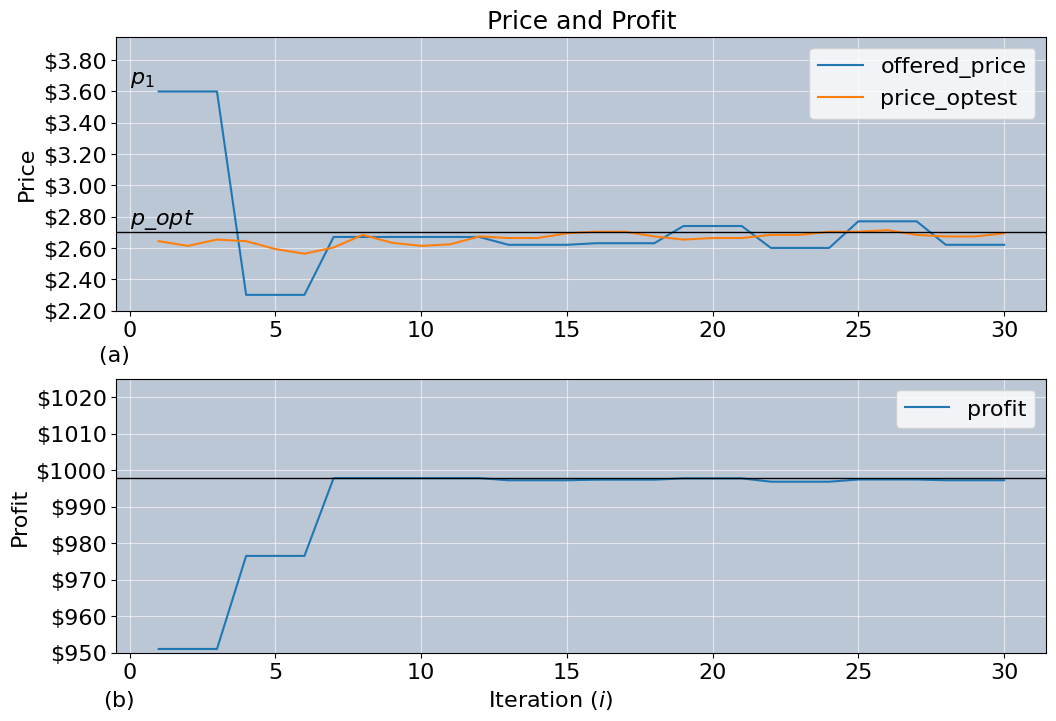

In [31]:
fig, axs = plt.subplots(nrows =2, ncols=1,figsize=(12, 8))

# change variable nambes for better understanding
df_ts_summary["offered_price"] = df_ts_summary["price_history"]
df_ts_summary["price_optest"] = df_ts_summary["price_optest_history"]
df_ts_summary["profit"] = df_ts_summary["profit_history"]

bp.lineplot(
    df_ts_summary, x ="n",
    y = ["offered_price", "price_optest"], 
    y_axis_label='Price',
     x_axis_label="(a)                                                                                                                                   ",
    y_currency="$",
    h_line =[p_opt],
    legend_loc = ("upper right"),
    title = "Price and Profit",
    y_lims = (2.2, 3.95),
    figsize=(12,6),
    ax = axs[0],
    annotate=[  ("$p_1$", (0,3.65)), ("$p\_opt$", (0, 2.75))] 
    )

background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
axs[0].set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
axs[0].grid(True, color=grid_color, alpha=grid_alpha)
plt.subplots_adjust(wspace=0.25, hspace=0.25)

# Profit
bp.lineplot(df_ts_summary, x="n",
    y = ["profit"],
    y_axis_label='Profit',
    x_axis_label="(b)                                                  Iteration ($i$)                                                                ",
    y_axis_format=".0f",
    y_currency="$",
    y_lims = (950, 1025),
    h_line = Profit_opt,
    figsize=(12,6),
    ax = axs[1]
)
background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
axs[1].set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
axs[1].grid(True, color=grid_color, alpha=grid_alpha)

plt.show()

Convergence looks reasonably good
* early phase (t ~ 1 - 10) 
  * Fast learning, large parameter moves, price swings. Normal.
* middle phase  (t~ 10 - 25)
  * Parameters stabilize:
  * v settles around optimum, similarly a, sigma\_log, p* 
* late phase (t ~ 25 - 30) ...
  * TS wiggle is normal
  * continuted exploration 
  * price continutes woble, as does p_opt_ext, this is normal due to exploration
  * flat surface near optimum, p*  ... small parameter noise 
  * potentially price grid could be improved ... jumping between grid points 2.72, , 2.82, 2.63
  * no runaway bias this basically looks good
* Potential improvements
  * increase price grid ... not sure this will help too much already within 2 digits
  * potentially reduce local min max after burn in 


In dynamic pricing with constant-elasticity demand, the profit function is locally flat around the optimal price. As a result, Thompson Sampling does not converge to a single price but instead samples within a near-optimal price region, leading to persistent but harmless price oscillations.

Ferira, Lee & Simchi-Levi, 2018, “Analytics for an online retailer: Demand forecasting and price optimization”, Explicitly notes that noise + flat revenue causes persistent variability.

Agrawal & GOyal (2012), Explicitly notes that noise + flat revenue causes persistent variability. Formalizes that TS samples among actions with similar expected reward. Flat reward ⇒ persistent exploration

den Boer, 2015, “Dynamic pricing and learning: historical origins, current research, and new directions” , Surveys in Operations Research. Survey paper, Describes that optimal price regions are often intervals, not points, TS and Bayesian pricing naturally cycle within these regions

# Profit over Time

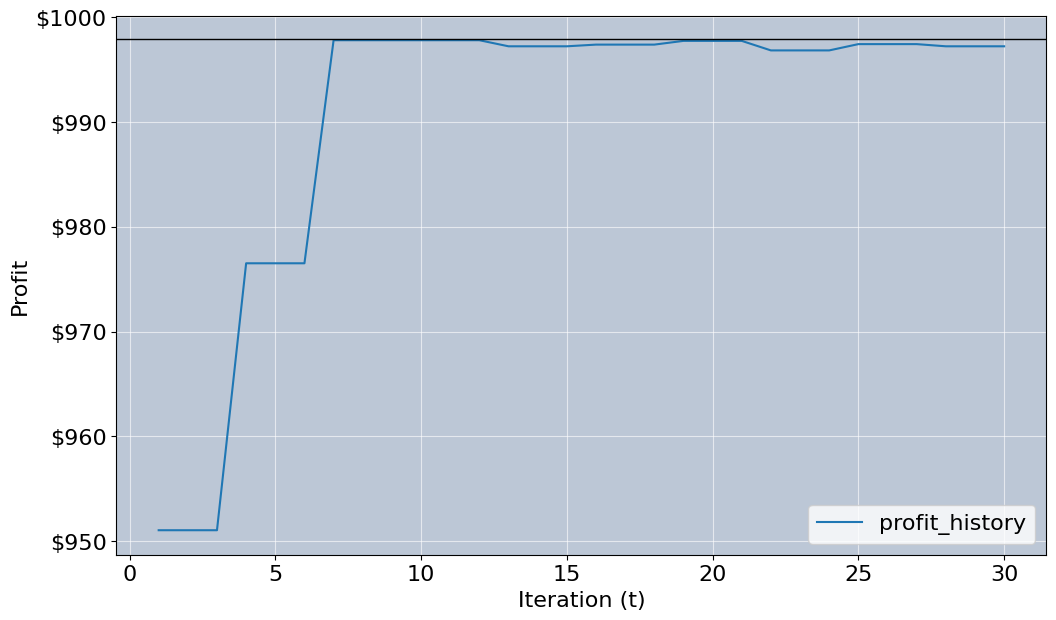

In [32]:
fig, ax = plt.subplots(figsize=(12, 7))
bp.lineplot(df_ts_summary, x="n",
    y = ["profit_history"],
    y_axis_label='Profit',
    x_axis_label='Iteration (t)',
    y_axis_format=".0f",
    y_currency="$",
    h_line = Profit_opt,
    figsize=(12,6),
    ax = ax
)
background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
ax.set_facecolor(background_color)
grid_color = "white"
grid_alpha = 0.6
ax.grid(True, color=grid_color, alpha=grid_alpha)
plt.show()


# Tightening

In [33]:
from utils_plot import plot_hdi_width_over_time

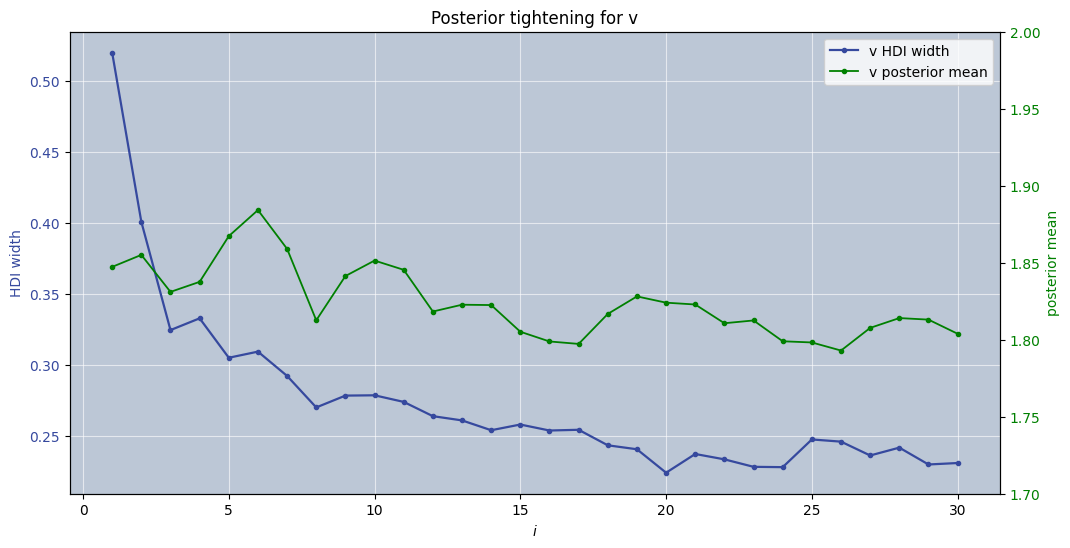

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

hdi_widths_v = plot_hdi_width_over_time(
    traces=_traces,
    ax=ax,
    var_names=("v",),
    hdi_prob=0.95,
    overlay_mean=True,
    mean_on_secondary_axis=True,
    secondary_linestyle = "-",
    secondary_marker = ".",
    secondary_line_color="green",
    show_grid=True,
    title="Posterior tightening for v",
    xlabel="$i$",
    ylabel="HDI width",
    line_color="#36499E",
    marker=".",
    y_lims2=(1.7, 2.0),
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

plt.show()

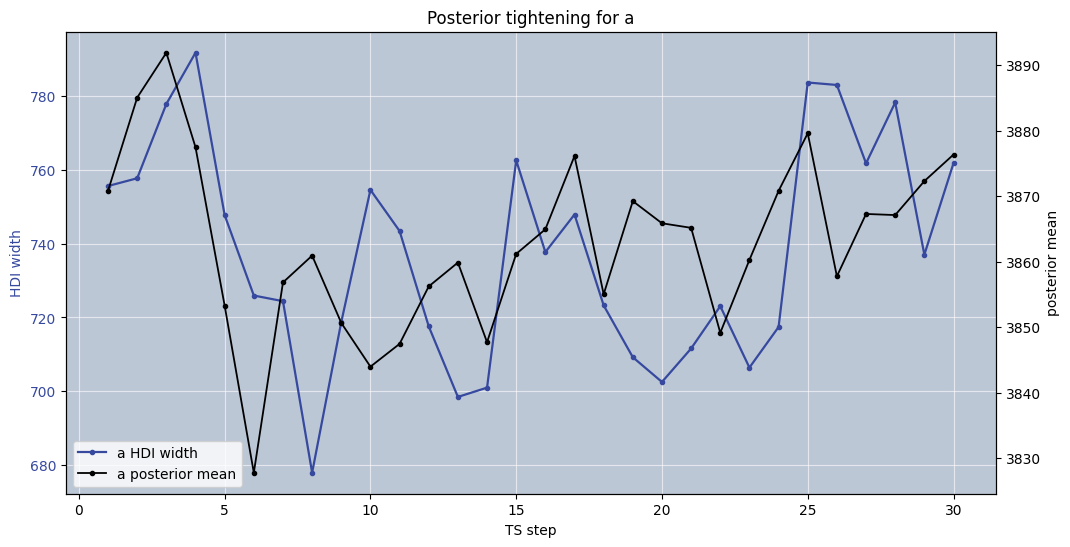

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))

hdi_widths_a = plot_hdi_width_over_time(
    traces=_traces,
    ax=ax,
    var_names=("a",),
    hdi_prob=0.95,
    overlay_mean=True,
    mean_on_secondary_axis=True,
    secondary_linestyle = "-",
    secondary_marker = ".",
    show_grid=True,
    title="Posterior tightening for a",
    xlabel="TS step",
    ylabel="HDI width",
    line_color="#36499E",
    marker=".",
)

plt.show()

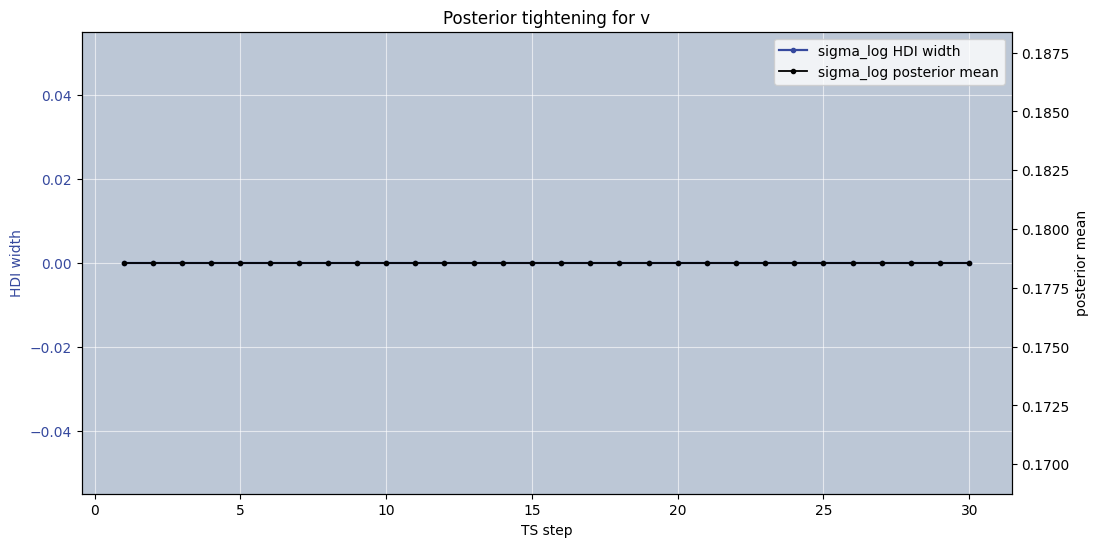

In [39]:
fig, ax = plt.subplots(figsize=(12, 6))

hdi_widgs_sigma = plot_hdi_width_over_time(
    traces=_traces,
    ax=ax,
    var_names=("sigma_log",),
    hdi_prob=0.94,
    overlay_mean=True,
    mean_on_secondary_axis=True,
        secondary_linestyle = "-",
    secondary_marker = ".",
    show_grid=True,
    title="Posterior tightening for v",
    xlabel="TS step",
    ylabel="HDI width",
    line_color="#36499E",
    marker=".",
)

plt.show()

# Density plots over time

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib as mpl
from matplotlib.colors import Normalize

In [41]:
from utils_plot import plot_kde_densities_at_prices

#### demand

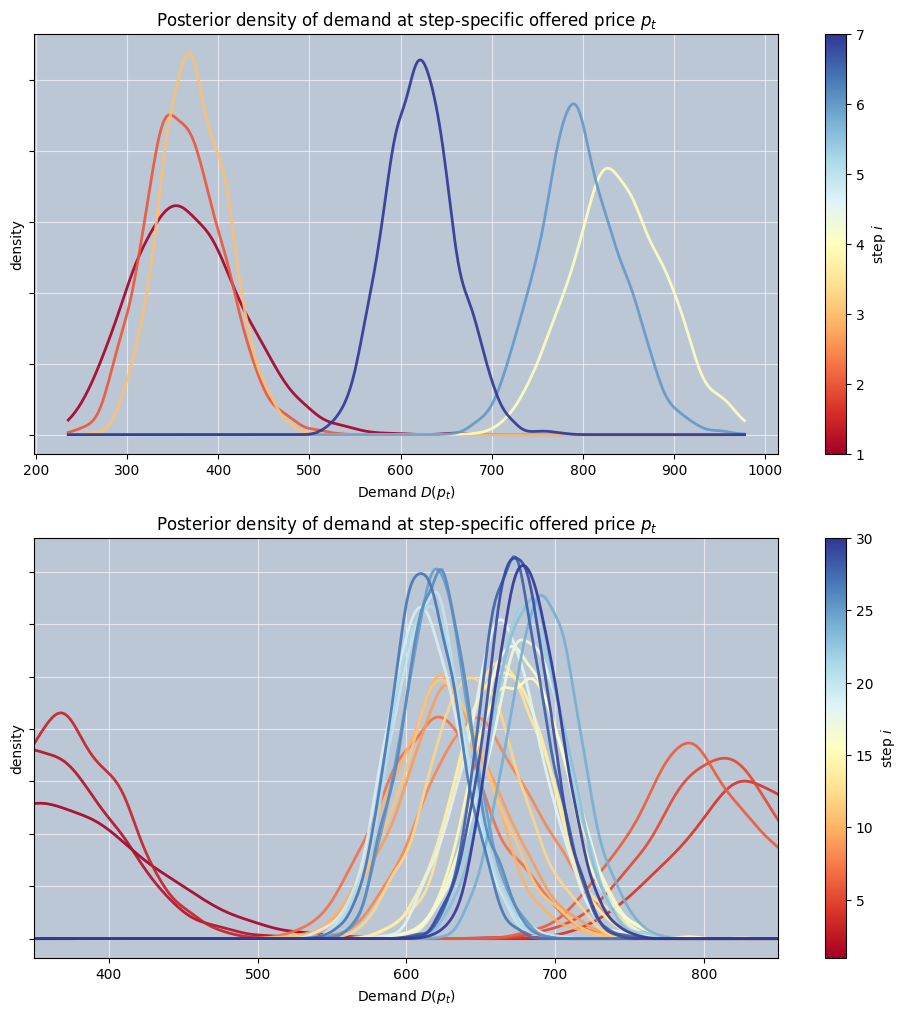

In [42]:
# demand
fig, axs = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))
# t starts at 1
plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    kde_plot_variable="demand",
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    ax=axs[0],
    cmap_name="RdYlBu",
    t_min=1,
    t_max=None,
    t_indices=[1,2,3,4,6,7,37,38],      #  price is hopping +/- around p_optext, function of price
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    )

#axs[0].set_xlim(350, 850)
axs[0].tick_params(axis='y', labelleft=False)

# t 1, 2 ... 30
plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    kde_plot_variable="demand",
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    ax=axs[1],
    cmap_name="RdYlBu",
    t_min=1,
    t_max=None,
    #t_indices=[1,2,3,4,5,6,7,8,9,25,26,30],      # example: [1, 3, 5, 10]
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    )

axs[1].set_xlim(350, 850)
axs[1].tick_params(axis='y', labelleft=False)

plt.show()

#### revenue
- revenue is subject to p_optest +/- changes

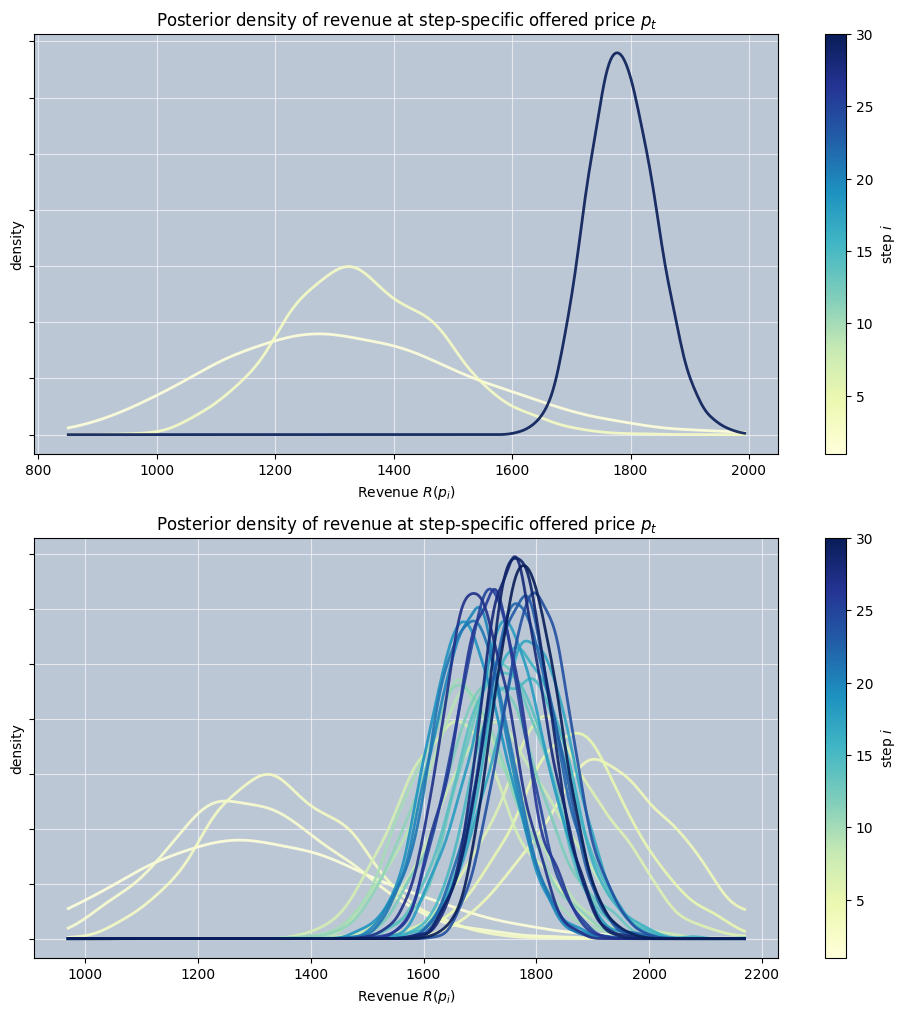

In [43]:
# revenue
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))
t_max=None
ax[0] = plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[0],
    kde_plot_variable="revenue",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    t_max = None,
    t_indices = [1, 3, 30],
    cmap_name="YlGnBu",   # "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax[0].set_xlim(1000, 2300) 
ax[0].tick_params(axis='y', labelleft=False)


ax[1] = plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[1],
    kde_plot_variable="revenue",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    t_max = None,
    cmap_name="YlGnBu",   # "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax[1].set_xlim(1300, 2100) 
ax[1].tick_params(axis='y', labelleft=False)


plt.show()

### price

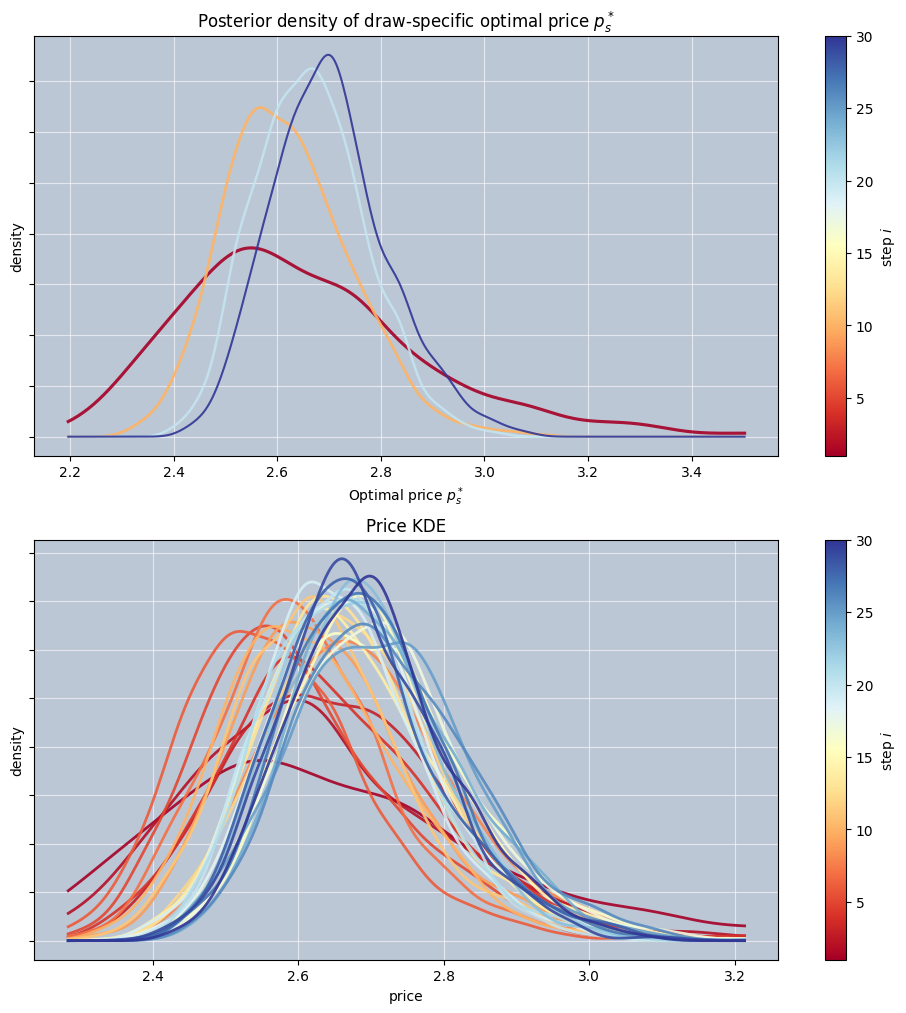

In [44]:
# price
# t starts at 1
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))


ax[0]=plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[0],
    kde_plot_variable="optimal_price",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    price_min=price_min,
    price_max=price_max,
    t_indices = [1,10,20,30,40],
    #colors=["#E2523D", "#FBF8BD", "#36499E"],
    closed_form_optimal_price=False,
    cmap_name= "RdYlBu",  # "YlGnBu", "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6", # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    linewidth_progression=True,
    linewidth_min=1.5,
    linewidth_max=2.25,
    reverse_linewidth_progression=True

)
#ax[0].set_xlim(2, 3.8) 
ax[0].tick_params(axis='y', labelleft=False)

ax[1]=plot_kde_densities_at_prices(
    traces=_traces,
    prices_history=prices_history,
    ax = ax[1],
    title="Price KDE",
    xlabel="price",
    kde_plot_variable="optimal_price",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    price_min=price_min,
    price_max=price_max,
    closed_form_optimal_price=False,
    cmap_name="RdYlBu",  # "viridis_r", "RdYlBu", YlGnBu
    show_colorbar=True,
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax[0].set_xlim(2, 3.8) 
ax[1].tick_params(axis='y', labelleft=False)

plt.show()


KDE tail bump density (early rounds) ... above
The graph above, posterior density of offered price $p^*$ shows a "boundary pile up" effect on the right edge of the tail. This is a KDE graph artifact. In the early parts of the TS simulation the posterior is wide with non-neglidgable density to the right of the price_max. As the posterior tightens and centers on the optimum price, the tail smooths out since most of the desity is closer to the optimum price with less density in the tails, and little beyound the maximum price.

#### profit

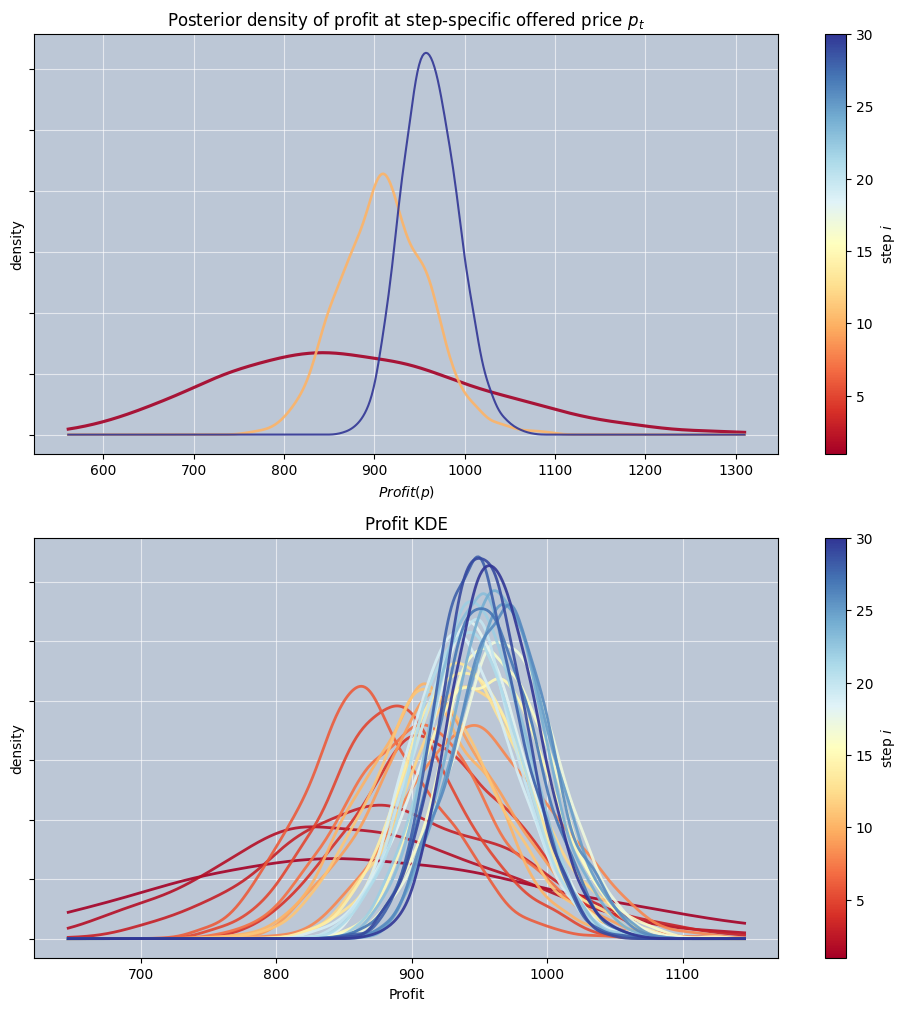

In [45]:
# profit
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(12, 12))

ax[0]=plot_kde_densities_at_prices(
    traces=_traces,
    ax = ax[0],
    prices_history=prices_history,
    kde_plot_variable="profit",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    t_indices = [1, 10, 30,40],
    cmap_name="RdYlBu",   # "viridis_r", "RdYlBu", "YlGnBu"
    background_color="#bcc7d6", # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
    linewidth_progression=True,
    linewidth_min=1.5,
    linewidth_max=2.25,
    reverse_linewidth_progression=True
)
ax[0].tick_params(axis='y', labelleft=False)


ax[1]=plot_kde_densities_at_prices(
    traces=_traces,
    ax = ax[1],
    prices_history=prices_history,
    title = "Profit KDE",
    xlabel="Profit",
    kde_plot_variable="profit",  
    variable_cost=variable_cost,
    fixed_cost=fixed_cost,
    cmap_name="RdYlBu",   # "viridis_r", "RdYlBu", YlGnBu, Blues, RdGnBu
    background_color="#bcc7d6" # #d9d9d9 medium grey, #e6e6e6 soft grey, #bcc7d6 slate
)

#ax.set_xlim(825, 1200) 
ax[1].tick_params(axis='y', labelleft=False)
plt.show()

Interpretation of the plots

* Profit KDE → uncertainty in the outcome of the price that was actually offered.

Over iterations:
* distributions narrow
* means move toward the optimum
* uncertainty shrinks.

Why decision-objective KDEs are more intuitive

* Profit and optimal price correspond to the real business objective.

* These quantities convert parameter uncertainty into decision uncertainty.

* A tightening KDE of profit or optimal price shows the algorithm converging toward the optimal decision.